# Cepheid — RV analysis

`cepheid_build.ipynb` produces a single 5000–5020 Å spectral fragment per LD
variant (no per-line synthesis). This notebook recovers radial velocities from
that fragment two ways:

1. **Full window** — cross-correlate the whole 20 Å fragment.
2. **Per-line windows** — cross-correlate small windows around six
   hand-picked Fe I lines. The half-width of each window is fitted
   independently per line by minimising the RMS between the recovered RV
   curve and the on-mesh true pulsation velocity.

Both are then compared against the on-mesh pulsation velocity (the "ground
truth") and across linear-LD coefficients to study the projection factor.


In [23]:
import sys, os
sys.path.append('/Users/mjablons/code/spice/src')
sys.path.append(os.path.dirname(os.path.abspath('cepheid_bundles.py')))

import warnings
import numpy as np
import jax.numpy as jnp
import matplotlib.pyplot as plt
import pandas as pd
from tqdm import tqdm
from astropy.io import fits
from astropy.table import Table
from scipy.interpolate import interp1d
from scipy.optimize import curve_fit
from scipy.signal.windows import tukey

from cepheid_bundles import CepheidBundle, LineSpectra, load_pickle

%matplotlib inline


## Load bundles and spectra

Each `spectra_dataset[variant]` is a dict keyed by line center; with the new build there is exactly one entry per variant — the full fragment, with `wavelengths` spanning 5000–5020 Å.


In [24]:
bundles = load_pickle('cepheid_bundles_vmicro.pkl')
spectra_dataset = load_pickle('cepheid_spectra_vmicro.pkl')

print('Bundles:        ', list(bundles.keys()))
print('Spectra variants:', list(spectra_dataset.keys()))

_first_variant = next(iter(spectra_dataset))
_first_ls = next(iter(spectra_dataset[_first_variant].values()))
print(
    f'Fragment for {_first_variant!r}: '
    f'{float(_first_ls.wavelengths.min()):.2f}–{float(_first_ls.wavelengths.max()):.2f} Å '
    f'({len(_first_ls.wavelengths)} points, {len(_first_ls.spectra)} snapshots)'
)


Bundles:         ['intensity', 'flux_linear_0.0', 'flux_linear_0.1', 'flux_linear_0.2', 'flux_linear_0.3', 'flux_linear_0.4', 'flux_linear_0.6', 'flux_linear_0.7', 'flux_linear_0.8', 'flux_linear_0.9', 'flux_linear_1.0']
Spectra variants: ['with_ld', 'flux_linear_0.0', 'flux_linear_0.1', 'flux_linear_0.2', 'flux_linear_0.3', 'flux_linear_0.4', 'flux_linear_0.6', 'flux_linear_0.7', 'flux_linear_0.8', 'flux_linear_0.9', 'flux_linear_1.0']
Fragment for 'with_ld': 5000.00–5020.00 Å (2000 points, 100 snapshots)


## Phase grid & SPIPS3 reference


In [25]:
PERIOD = 5.366265401100268
TIMESERIES = jnp.linspace(0, PERIOD, 100)
phases = (TIMESERIES / PERIOD) % 1.0
PHASE_NUMPY = np.asarray(phases)

with fits.open('delta_cep.fits', ignore_missing_simple=True) as hdul:
    pulsation_data = Table(hdul[2].data)


## Pulsation-velocity sanity check

Maximum projected radial velocity on the visible hemisphere of the `intensity` bundle vs SPIPS3 `Vpuls`.


In [26]:
def signed_radial_max(model, vector_attr: str) -> float:
    """Max signed (sign by radial direction) magnitude of a per-face vector field on the visible hemisphere."""
    visible = model.mus > 0
    vectors = getattr(model, vector_attr)[visible]
    centers = model.centers[visible]
    magnitudes = np.linalg.norm(vectors, axis=1)
    normals = centers / np.linalg.norm(centers, axis=1, keepdims=True)
    radial = np.sum(vectors * normals, axis=1)
    return float(np.max(np.sign(radial) * magnitudes))


pulsation_velocities = np.array(
    [signed_radial_max(m, 'pulsation_velocities') for m in bundles['intensity'].snapshots]
)
pulsation_offsets = np.array(
    [signed_radial_max(m, 'center_pulsation_offsets') for m in bundles['intensity'].snapshots]
)


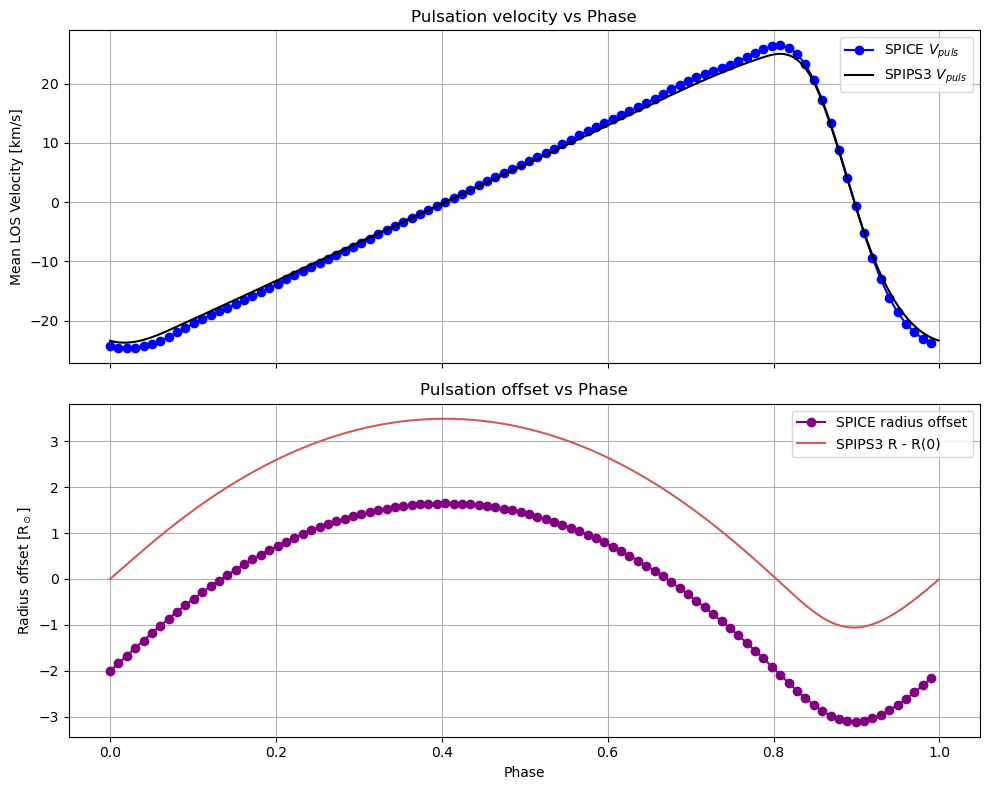

In [27]:
fig, ax = plt.subplots(2, 1, figsize=(10, 8), sharex=True)
ax[0].plot(phases[:-1], pulsation_velocities[:-1], 'o-', color='blue', label=r'SPICE $V_{puls}$')
ax[0].plot(pulsation_data['PHASE'], pulsation_data['Vpuls'], color='black', label=r'SPIPS3 $V_{puls}$')
ax[0].set_ylabel('Mean LOS Velocity [km/s]'); ax[0].set_title('Pulsation velocity vs Phase')
ax[0].grid(True); ax[0].legend()

ax[1].plot(phases[:-1], pulsation_offsets[:-1], 'o-', color='purple', label='SPICE radius offset')
ax[1].plot(pulsation_data['PHASE'], pulsation_data['R'] - pulsation_data['R'][0],
           color='indianred', label='SPIPS3 R - R(0)')
ax[1].set_ylabel(r'Radius offset [R$_\odot$]'); ax[1].set_xlabel('Phase')
ax[1].set_title('Pulsation offset vs Phase'); ax[1].grid(True); ax[1].legend()
plt.tight_layout(); plt.show()


## Cross-correlation RV measurement

FFT-style normalised CCF on a log-wavelength grid, with a robust local-Gaussian peak refine. Positive RV = observed redshifted relative to template.


In [28]:
C_KMS = 299792.458


def _gaussian_peak_fit(v, c, top_frac=0.5, fallback=None):
    v = np.asarray(v, dtype=float)
    c = np.asarray(c, dtype=float)

    k = int(np.nanargmax(c))
    if fallback is None:
        fallback = float(v[k])

    c_med = float(np.nanmedian(c))
    c_max = float(c[k])
    if not np.isfinite(c_max) or c_max <= c_med:
        return fallback, np.nan

    thresh = c_med + top_frac * (c_max - c_med)
    left = k
    while left > 0 and c[left - 1] > thresh:
        left -= 1
    right = k
    while right < len(c) - 1 and c[right + 1] > thresh:
        right += 1

    pad = 2
    left = max(0, left - pad)
    right = min(len(c) - 1, right + pad)
    if right - left + 1 < 5:
        return fallback, np.nan

    vv = v[left:right + 1]
    cc = c[left:right + 1]

    def model(vv, A, v0, sigma, c0):
        return A * np.exp(-0.5 * ((vv - v0) / sigma) ** 2) + c0

    dv = abs(v[1] - v[0])
    width_guess = max(2 * dv, 0.25 * (vv[-1] - vv[0]))
    p0 = [c_max - c_med, fallback, width_guess, c_med]
    bounds = (
        [0.0, vv[0], dv / 2, -np.inf],
        [np.inf, vv[-1], max(vv[-1] - vv[0], dv), np.inf],
    )
    try:
        popt, pcov = curve_fit(model, vv, cc, p0=p0, bounds=bounds, maxfev=5000)
    except (RuntimeError, ValueError):
        return fallback, np.nan

    v0 = float(popt[1])
    if not np.isfinite(v0):
        return fallback, np.nan

    err = np.nan
    if pcov is not None and np.all(np.isfinite(pcov)):
        err = float(np.sqrt(pcov[1, 1]))
    return v0, err


def _normalized_lag_ccf(t, o, max_lag):
    lags = np.arange(-max_lag, max_lag + 1)
    ccf = np.full_like(lags, np.nan, dtype=float)
    for j, lag in enumerate(lags):
        if lag > 0:
            tt, oo = t[:-lag], o[lag:]
        elif lag < 0:
            tt, oo = t[-lag:], o[:lag]
        else:
            tt, oo = t, o
        good = np.isfinite(tt) & np.isfinite(oo)
        tt, oo = tt[good], oo[good]
        if tt.size < 5:
            continue
        tt = tt - np.mean(tt)
        oo = oo - np.mean(oo)
        denom = np.sqrt(np.sum(tt ** 2) * np.sum(oo ** 2))
        if denom > 0:
            ccf[j] = np.sum(tt * oo) / denom
    return lags, ccf


def calculate_rv_fft(template_flux, observed_flux, wavelengths,
                     velocity_max=150.0, oversample=4,
                     apodize=0.1, refine="gaussian",
                     gaussian_top_frac=0.5,
                     interp_kind="linear",
                     max_overlap_frac=0.5,
                     use_line_depth=True):
    wl = np.asarray(wavelengths, dtype=float)
    t_in = np.asarray(template_flux, dtype=float)
    o_in = np.asarray(observed_flux, dtype=float)

    if wl.size < 8 or t_in.size != wl.size or o_in.size != wl.size:
        raise ValueError("Inputs must be matching 1-D arrays, length >= 8.")
    if np.any(np.diff(wl) <= 0):
        raise ValueError("wavelengths must be strictly increasing.")

    lnwl_in = np.log(wl)
    n = int(oversample * len(wl))
    n += n % 2
    lnlam = np.linspace(lnwl_in[0], lnwl_in[-1], n)
    dv_pix = C_KMS * (lnlam[1] - lnlam[0])

    def _resample(y):
        return interp1d(lnwl_in, y, kind=interp_kind, bounds_error=False, fill_value=np.nan)(lnlam)

    t = _resample(t_in)
    o = _resample(o_in)
    good = np.isfinite(t) & np.isfinite(o)
    if good.sum() < 8:
        raise ValueError("Too few finite overlapping pixels.")
    idx = np.flatnonzero(good)
    seg = slice(idx[0], idx[-1] + 1)
    t = t[seg].copy()
    o = o[seg].copy()
    for a in (t, o):
        bad = ~np.isfinite(a)
        if bad.any():
            a[bad] = np.nanmedian(a)

    if use_line_depth:
        t = 1.0 - t
        o = 1.0 - o

    t = t - np.nanmedian(t)
    o = o - np.nanmedian(o)

    n_eff = t.size
    if apodize > 0:
        w = tukey(n_eff, apodize)
        t *= w
        o *= w

    max_lag_req = int(np.ceil(velocity_max / dv_pix))
    max_lag_overlap = int(np.floor(n_eff * max_overlap_frac))
    max_lag = min(max_lag_req, max_lag_overlap)
    if max_lag < 2:
        raise ValueError(
            f"n_eff={n_eff} too small for velocity_max={velocity_max} km/s at dv_pix={dv_pix:.3f} km/s."
        )

    lags, ccf = _normalized_lag_ccf(t, o, max_lag)
    velocities = lags * dv_pix
    k = int(np.nanargmax(ccf))
    best_velocity = float(velocities[k])
    best_velocity_err = np.nan

    at_edge = k <= 1 or k >= len(ccf) - 2
    if at_edge:
        warnings.warn(
            f"CCF peak at edge: v={best_velocity:.2f} km/s. Increase velocity_max or inspect this window.",
            RuntimeWarning,
        )
        return best_velocity, best_velocity_err, ccf, velocities

    if refine == "parabolic":
        y0, y1, y2 = ccf[k - 1], ccf[k], ccf[k + 1]
        d = y0 - 2.0 * y1 + y2
        if np.isfinite(d) and d < 0:
            best_velocity += 0.5 * (y0 - y2) / d * dv_pix
    elif refine == "gaussian":
        v_fit, e_fit = _gaussian_peak_fit(velocities, ccf, top_frac=gaussian_top_frac, fallback=best_velocity)
        if np.isfinite(v_fit) and velocities[0] <= v_fit <= velocities[-1]:
            best_velocity = float(v_fit)
            best_velocity_err = e_fit

    return best_velocity, best_velocity_err, ccf, velocities


### Inject and recover a known velocity


In [29]:
ls_full = next(iter(spectra_dataset['with_ld'].values()))
template_wl   = np.asarray(ls_full.wavelengths)
template_flux = np.asarray(ls_full.template[:, 0] / ls_full.template[:, 1])

v_true = 25.0
wl_shifted = template_wl * (1 + v_true / C_KMS)
flux_obs = np.interp(template_wl, wl_shifted, template_flux, left=1.0, right=1.0)

v_rec, v_err, _, _ = calculate_rv_fft(template_flux, flux_obs, template_wl)
print(f'injected {v_true:+.2f}, recovered {v_rec:+.3f} ± {v_err:.3f} km/s')


injected +25.00, recovered +25.032 ± 0.001 km/s


## Selected Fe I lines

Six absorption lines hand-picked from a line list at the Cepheid's
atmospheric parameters. No peak detection — these are the lines we want to
work with, and only these.

| line | EP [eV] | notes |
|---|---|---|
| Fe I 5001.863 | 3.88 | clean, moderate depth |
| Fe I 5002.791 | 3.40 | clean, moderate |
| Fe I 5006.119 | 2.83 | strong, one of the better anchors in this window |
| Fe I 5007.212 | 4.99 | weaker, clean |
| Fe I 5014.942 | 3.94 | clean, good depth |
| Fe I 5016.477 | 4.26 | clean |


In [30]:
FE_I_LINES = [
    ('Fe I 5001.863', 5001.863, 3.88),
    ('Fe I 5002.791', 5002.791, 3.40),
    ('Fe I 5006.119', 5006.119, 2.83),
    ('Fe I 5007.212', 5007.212, 4.99),
    ('Fe I 5014.942', 5014.942, 3.94),
    ('Fe I 5016.477', 5016.477, 4.26),
]

LINE_NAMES = [name for name, _, _ in FE_I_LINES]
LINE_CENTRES = np.array([lc for _, lc, _ in FE_I_LINES])
LINE_EPS = np.array([ep for _, _, ep in FE_I_LINES])

ls_with_ld = next(iter(spectra_dataset['with_ld'].values()))
template_wl = np.asarray(ls_with_ld.wavelengths)
template_flux = np.asarray(ls_with_ld.template[:, 0] / ls_with_ld.template[:, 1])

print(f'{len(FE_I_LINES)} Fe I lines selected:')
for name, lc, ep in FE_I_LINES:
    idx = int(np.argmin(np.abs(template_wl - lc)))
    depth = 1.0 - float(template_flux[idx])
    print(f'  {name:>16s}  λ = {lc:.3f} Å  EP = {ep:.2f} eV  depth ≈ {depth:.3f}')


6 Fe I lines selected:
     Fe I 5001.863  λ = 5001.863 Å  EP = 3.88 eV  depth ≈ 0.036
     Fe I 5002.791  λ = 5002.791 Å  EP = 3.40 eV  depth ≈ 0.015
     Fe I 5006.119  λ = 5006.119 Å  EP = 2.83 eV  depth ≈ 0.036
     Fe I 5007.212  λ = 5007.212 Å  EP = 4.99 eV  depth ≈ 0.074
     Fe I 5014.942  λ = 5014.942 Å  EP = 3.94 eV  depth ≈ 0.100
     Fe I 5016.477  λ = 5016.477 Å  EP = 4.26 eV  depth ≈ 0.014


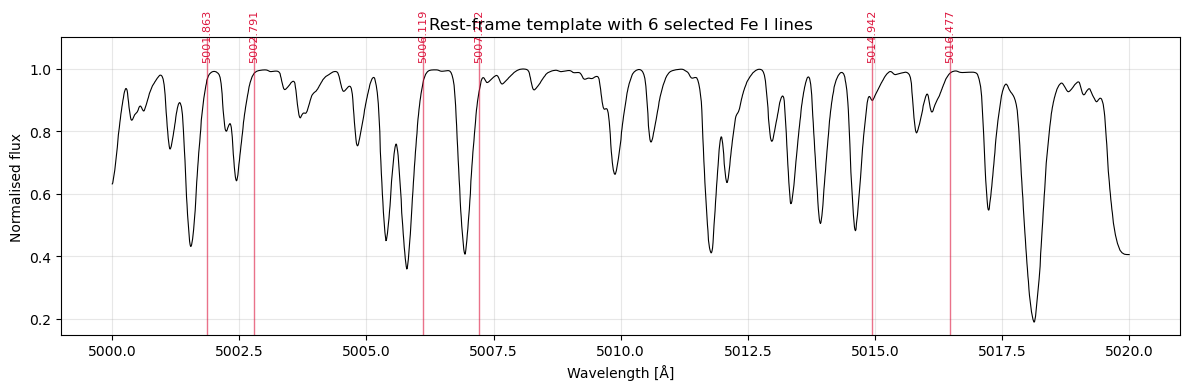

In [31]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(template_wl, template_flux, color='black', lw=0.8, label='Template (with LD)')
for name, lc, ep in FE_I_LINES:
    ax.axvline(lc, color='crimson', alpha=0.6, lw=1.0)
    ax.text(lc, 1.02, name.replace('Fe I ', ''),
            rotation=90, ha='center', va='bottom', fontsize=8, color='crimson')
ax.set_xlabel('Wavelength [Å]')
ax.set_ylabel('Normalised flux')
ax.set_ylim(top=1.10)
ax.set_title(f'Rest-frame template with {len(FE_I_LINES)} selected Fe I lines')
ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()


## Per-line half-width optimisation

For each Fe I line, sweep candidate half-widths and pick the one that
minimises the RMS between the recovered RV curve and the on-mesh true
pulsation velocity (after a per-line linear projection-factor fit). No line
is treated as contaminating any other — we trust the manually-picked centres
and let the CCF use whatever spectral structure happens to fall inside each
window.


In [32]:
def measure_rvs_in_window(line_spectra: LineSpectra, wl_min: float, wl_max: float,
                          oversample: int = 5) -> np.ndarray:
    """Return RV (km/s) per snapshot inside [wl_min, wl_max]."""
    wl = np.asarray(line_spectra.wavelengths)
    mask = (wl >= wl_min) & (wl <= wl_max)
    wl_m = wl[mask]
    if wl_m.size < 8:
        return np.full(len(line_spectra.spectra), np.nan)
    template = np.asarray(line_spectra.template[mask, 0] / line_spectra.template[mask, 1])
    rvs = [0.0]
    for spec in line_spectra.spectra[1:]:
        spec = np.asarray(spec)
        obs = spec[mask, 0] / spec[mask, 1]
        try:
            rv, _, _, _ = calculate_rv_fft(template, obs, wl_m, oversample=oversample)
        except (ValueError, RuntimeError):
            rv = np.nan
        rvs.append(rv)
    return np.array(rvs)


def _best_p(rv, truth):
    rv = np.asarray(rv, dtype=float)[1:]
    truth = np.asarray(truth, dtype=float)[1:]
    good = np.isfinite(rv) & np.isfinite(truth)
    if good.sum() < 3 or np.sum(rv[good] ** 2) == 0:
        return np.nan, np.nan
    p = float(np.sum(rv[good] * truth[good]) / np.sum(rv[good] ** 2))
    res = truth[good] - p * rv[good]
    return p, float(np.sqrt(np.mean(res ** 2)))


truth_curve = pulsation_velocities - pulsation_velocities[0]

# A window of half-width hw covers ±(c·hw/λ) km/s in wavelength. The default CCF
# uses max_overlap_frac=0.5, so the lag grid only spans HALF that — i.e. the CCF
# can search ±(c·hw/λ)/2 km/s. To resolve a peak at ±RV_max without railing out,
# we need hw ≥ 1.5 · RV_max · λ / c (50% margin).
RV_MAX = float(np.max(np.abs(truth_curve)))
WL_REF = float(template_wl.mean())
MIN_SAFE_HW = 1.5 * RV_MAX * WL_REF / C_KMS

HALF_WIDTH_GRID_FULL = np.array([
    0.08, 0.10, 0.12, 0.15, 0.18, 0.20, 0.22, 0.25, 0.28,
    0.30, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60, 0.70, 0.80,
    0.90, 1.00, 1.20, 1.50,
])
HALF_WIDTH_GRID = HALF_WIDTH_GRID_FULL[HALF_WIDTH_GRID_FULL >= MIN_SAFE_HW]
dropped = HALF_WIDTH_GRID_FULL[HALF_WIDTH_GRID_FULL < MIN_SAFE_HW]
print(f'V_puls amplitude on visible hemisphere: ±{RV_MAX:.1f} km/s')
print(f'Minimum safe half-width @ {WL_REF:.0f} Å: {MIN_SAFE_HW:.3f} Å')
if len(dropped):
    print(f'Dropped {len(dropped)} widths that would rail the CCF lag grid: '
          f'{[float(x) for x in dropped]}')

full_rv_curve = measure_rvs_in_window(
    ls_with_ld, float(template_wl.min()), float(template_wl.max())
)

per_line_records = []
per_line_curves = {}
with warnings.catch_warnings():
    # Per-snapshot edge warnings are expected for borderline-narrow widths;
    # the sweep will reject those widths via their RMS, no need to spam stderr.
    warnings.filterwarnings('ignore', category=RuntimeWarning,
                            message=r'CCF peak at edge')
    for name, lc, ep in tqdm(FE_I_LINES, desc='Fe I lines'):
        for hw in HALF_WIDTH_GRID:
            a, b = float(lc - hw), float(lc + hw)
            if a < template_wl.min() or b > template_wl.max():
                continue
            rv = measure_rvs_in_window(ls_with_ld, a, b)
            p, rms_truth = _best_p(rv, truth_curve)
            rms_full = float(np.sqrt(np.nanmean((rv[1:] - full_rv_curve[1:]) ** 2)))
            per_line_records.append({
                'line': name, 'centre': lc, 'EP_eV': ep, 'half_width': float(hw),
                'p': p, 'rms_vs_truth': rms_truth, 'rms_vs_full': rms_full,
                'n_finite': int(np.sum(np.isfinite(rv[1:]))),
            })
            per_line_curves.setdefault(name, {})[float(hw)] = rv

per_line_df = pd.DataFrame(per_line_records)
per_line_df.head()


V_puls amplitude on visible hemisphere: ±50.7 km/s
Minimum safe half-width @ 5010 Å: 1.271 Å
Dropped 21 widths that would rail the CCF lag grid: [0.08, 0.1, 0.12, 0.15, 0.18, 0.2, 0.22, 0.25, 0.28, 0.3, 0.35, 0.4, 0.45, 0.5, 0.55, 0.6, 0.7, 0.8, 0.9, 1.0, 1.2]


Fe I lines: 100%|██████████| 6/6 [00:19<00:00,  3.20s/it]


,line,centre,EP_eV,half_width,p,rms_vs_truth,rms_vs_full,n_finite
0,Fe I 5001.863,5001.863,3.88,1.5,1.312561,0.309622,0.333041,99
1,Fe I 5002.791,5002.791,3.40,1.5,1.340018,0.342034,0.143217,99
2,Fe I 5006.119,5006.119,2.83,1.5,1.338239,0.469707,0.188198,99
3,Fe I 5007.212,5007.212,4.99,1.5,1.402461,0.677965,1.308293,99
4,Fe I 5014.942,5014.942,3.94,1.5,1.322312,0.376857,0.187683,99


In [33]:
# Best half-width per line: minimum RMS-vs-truth among widths where (almost)
# every snapshot converged.
per_line_summary_rows = []
for name, lc, ep in FE_I_LINES:
    sub = per_line_df[per_line_df['line'] == name].copy()
    sub_clean = sub[sub['n_finite'] >= 95]
    if sub_clean.empty:
        sub_clean = sub
    i = sub_clean['rms_vs_truth'].idxmin()
    r = sub_clean.loc[i]
    per_line_summary_rows.append({
        'line': name, 'EP_eV': ep, 'centre': lc,
        'best_half_width_Å': float(r['half_width']),
        'window_width_Å': 2 * float(r['half_width']),
        'p': float(r['p']),
        'RMS_vs_truth_kms': float(r['rms_vs_truth']),
        'RMS_vs_full_kms': float(r['rms_vs_full']),
        'n_finite': int(r['n_finite']),
    })

per_line_summary = pd.DataFrame(per_line_summary_rows).set_index('line')

# Per-line best half-width as a {name: hw} dict for use in the window definition.
LINE_HALF_WIDTHS = {row.name: float(row['best_half_width_Å'])
                    for _, row in per_line_summary.iterrows()}
per_line_summary


,EP_eV,centre,best_half_width_Å,window_width_Å,p,RMS_vs_truth_kms,RMS_vs_full_kms,n_finite
line,,,,,,,,
Fe I 5001.863,3.88,5001.863,1.5,3.0,1.312561,0.309622,0.333041,99
Fe I 5002.791,3.40,5002.791,1.5,3.0,1.340018,0.342034,0.143217,99
Fe I 5006.119,2.83,5006.119,1.5,3.0,1.338239,0.469707,0.188198,99
Fe I 5007.212,4.99,5007.212,1.5,3.0,1.402461,0.677965,1.308293,99
Fe I 5014.942,3.94,5014.942,1.5,3.0,1.322312,0.376857,0.187683,99
Fe I 5016.477,4.26,5016.477,1.5,3.0,1.331802,0.930810,0.535632,99


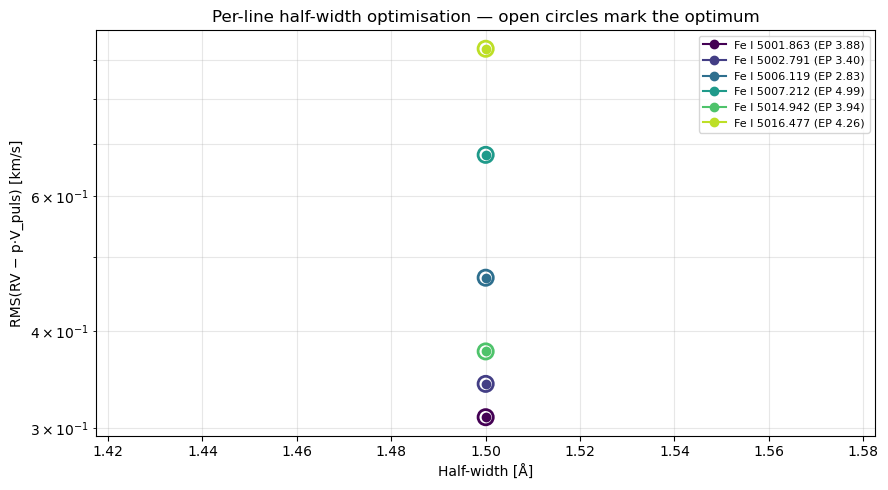

In [34]:
fig, ax = plt.subplots(figsize=(9, 5))
colors = plt.cm.viridis(np.linspace(0, 0.9, len(FE_I_LINES)))
for (name, lc, ep), color in zip(FE_I_LINES, colors):
    sub = per_line_df[per_line_df['line'] == name].sort_values('half_width')
    ax.plot(sub['half_width'], sub['rms_vs_truth'], 'o-', color=color,
            label=f'{name} (EP {ep:.2f})')
    best_hw = per_line_summary.loc[name, 'best_half_width_Å']
    best_rms = per_line_summary.loc[name, 'RMS_vs_truth_kms']
    ax.scatter([best_hw], [best_rms], s=120, facecolor='none',
               edgecolor=color, lw=2, zorder=5)

ax.set_yscale('log')
ax.set_xlabel('Half-width [Å]')
ax.set_ylabel('RMS(RV − p·V_puls) [km/s]')
ax.set_title('Per-line half-width optimisation — open circles mark the optimum')
ax.legend(fontsize=8, loc='best')
ax.grid(True, which='both', alpha=0.3)
plt.tight_layout(); plt.show()


## Define analysis windows

One full-fragment window plus, for each Fe I line, a window of the
optimised per-line half-width centred on the line.


In [35]:
windows = {'full': (float(template_wl.min()), float(template_wl.max()))}
for name, lc, ep in FE_I_LINES:
    hw = LINE_HALF_WIDTHS[name]
    key = name.replace('Fe I ', '')
    windows[key] = (float(lc - hw), float(lc + hw))

print('Analysis windows:')
for k, (a, b) in windows.items():
    print(f'  {k:>10s}: [{a:8.3f}, {b:8.3f}] Å  ({b - a:.2f} Å wide)')


Analysis windows:
        full: [5000.000, 5020.000] Å  (20.00 Å wide)
    5001.863: [5000.363, 5003.363] Å  (3.00 Å wide)
    5002.791: [5001.291, 5004.291] Å  (3.00 Å wide)
    5006.119: [5004.619, 5007.619] Å  (3.00 Å wide)
    5007.212: [5005.712, 5008.712] Å  (3.00 Å wide)
    5014.942: [5013.442, 5016.442] Å  (3.00 Å wide)
    5016.477: [5014.977, 5017.977] Å  (3.00 Å wide)


## Compute RVs for each window

For every (variant, window) pair we cross-correlate every snapshot against
the t = 0 template. The first snapshot is set to RV = 0 by definition (it
*is* the template).


In [36]:
variants = list(spectra_dataset.keys())
rv_table: dict[str, dict[str, np.ndarray]] = {variant: {} for variant in variants}

for variant in tqdm(variants, desc='variants'):
    ls = next(iter(spectra_dataset[variant].values()))
    for win_name, (a, b) in windows.items():
        rv_table[variant][win_name] = measure_rvs_in_window(ls, a, b)

rvs_with_ld_full = rv_table['with_ld']['full']
print('shape (snapshots,):', rvs_with_ld_full.shape)


variants: 100%|██████████| 11/11 [05:42<00:00, 31.17s/it]

shape (snapshots,): (100,)


## RV curves: full window vs per-line windows

Single-line windows are noisier than the full fragment, but bias differences
(per-line scatter, asymmetric line shape) are what we care about.


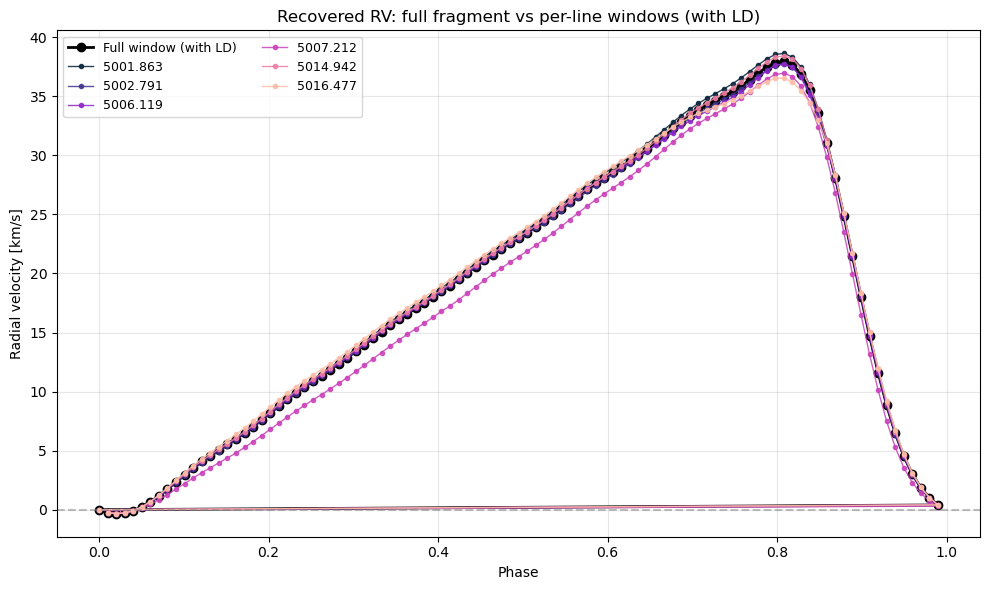

In [37]:
import cmasher as cmr
cmap = cmr.bubblegum

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(phases[1:], rv_table['with_ld']['full'][1:],
        color='black', lw=2, marker='o', label='Full window (with LD)')

line_keys = [k for k in windows if k != 'full']
norm = plt.Normalize(0, max(len(line_keys) - 1, 1))
for i, key in enumerate(line_keys):
    color = cmap(norm(i))
    ax.plot(phases[1:], rv_table['with_ld'][key][1:],
            color=color, lw=1.0, alpha=0.85, marker='.', label=key)

ax.axhline(0, color='gray', linestyle='--', alpha=0.5)
ax.set_xlabel('Phase')
ax.set_ylabel('Radial velocity [km/s]')
ax.set_title('Recovered RV: full fragment vs per-line windows (with LD)')
ax.legend(ncol=2, fontsize=9, loc='best')
ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()


## Trailed dynamic spectrum

Top: phase-coloured profile overlay of the full fragment. Bottom: residual
flux (per-snapshot minus the median profile) as a phase × wavelength map;
selected Fe I line centres marked.


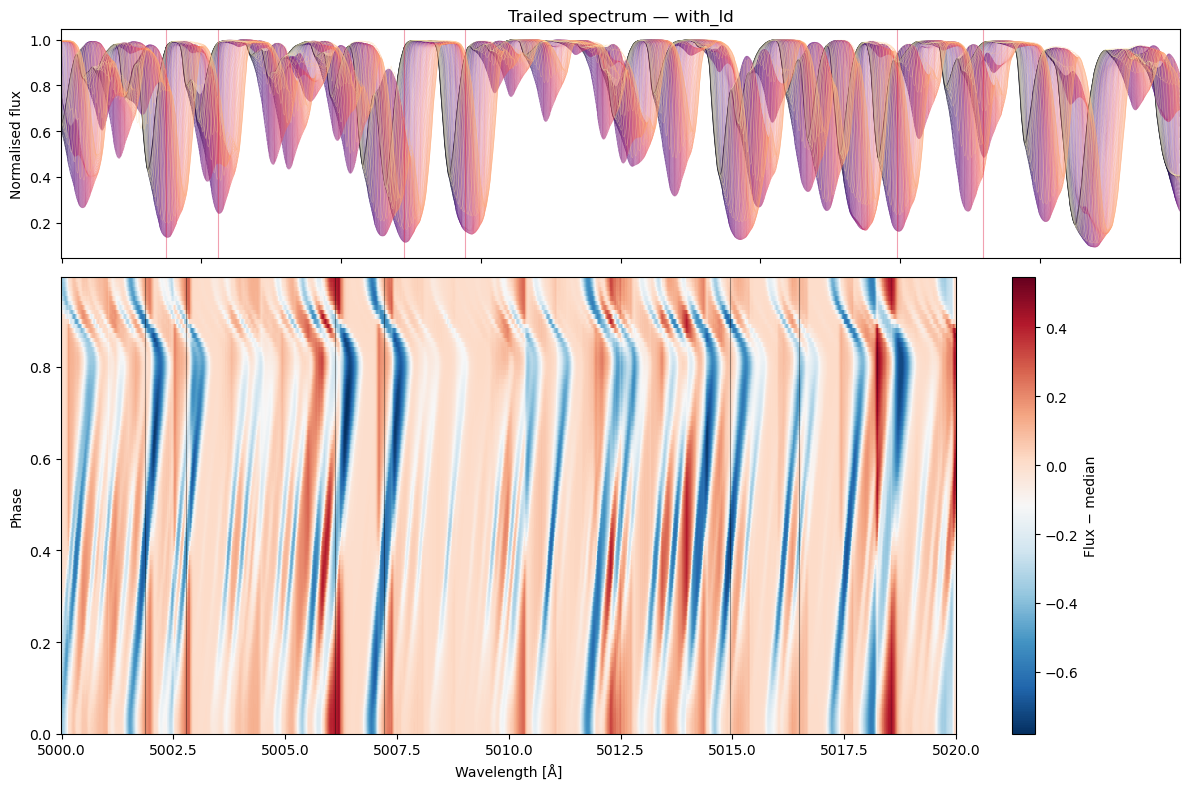

In [38]:
def flux_matrix(line_spectra: LineSpectra) -> np.ndarray:
    return np.stack([np.asarray(s[:, 0] / s[:, 1]) for s in line_spectra.spectra])


def plot_trailed_spectrum(variant: str = 'with_ld'):
    ls = next(iter(spectra_dataset[variant].values()))
    wl = np.asarray(ls.wavelengths)
    F = flux_matrix(ls)

    order = np.argsort(PHASE_NUMPY)
    P = PHASE_NUMPY[order]
    F = F[order]

    norm = plt.Normalize(0, 1)
    fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True,
                              gridspec_kw={'height_ratios': [1, 2]})

    for ph, profile in zip(P, F):
        axes[0].plot(wl, profile, color=plt.cm.magma(norm(ph)), lw=0.4, alpha=0.4)
    for lc in LINE_CENTRES:
        axes[0].axvline(lc, color='crimson', alpha=0.4, lw=0.8)
    axes[0].set_ylabel('Normalised flux')
    axes[0].set_title(f'Trailed spectrum — {variant}')

    median_profile = np.nanmedian(F, axis=0)
    residual = F - median_profile
    im = axes[1].pcolormesh(wl, P, residual, shading='auto', cmap='RdBu_r')
    for lc in LINE_CENTRES:
        axes[1].axvline(lc, color='black', alpha=0.4, lw=0.8)
    axes[1].set_xlabel('Wavelength [Å]')
    axes[1].set_ylabel('Phase')
    fig.colorbar(im, ax=axes[1], label='Flux − median')

    plt.tight_layout()
    return fig


plot_trailed_spectrum('with_ld')
plt.show()


## With LD vs no LD vs true pulsation velocity

`flux_linear_0.0` is the no-limb-darkening case; `flux_linear_1.0` is the
maximally-darkened linear-LD case; `with_ld` uses the intensity-grid LD
baked into the emulator. The "true" curve is the on-mesh signed pulsation
velocity offset from t = 0.


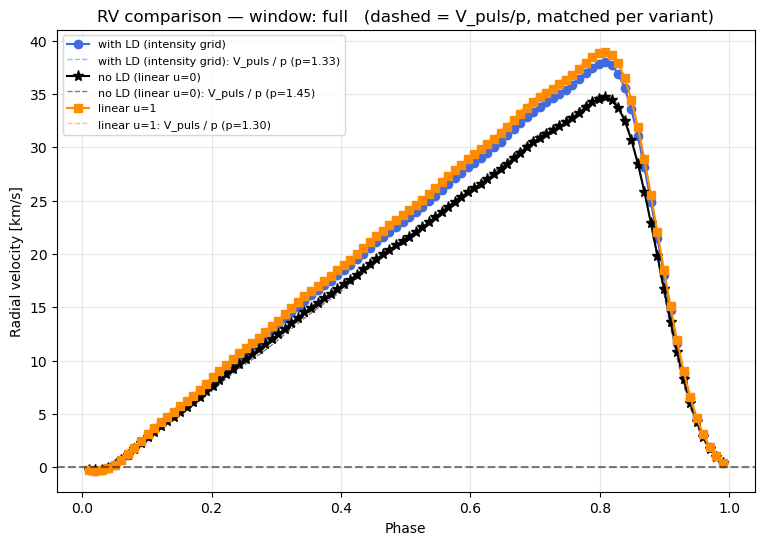

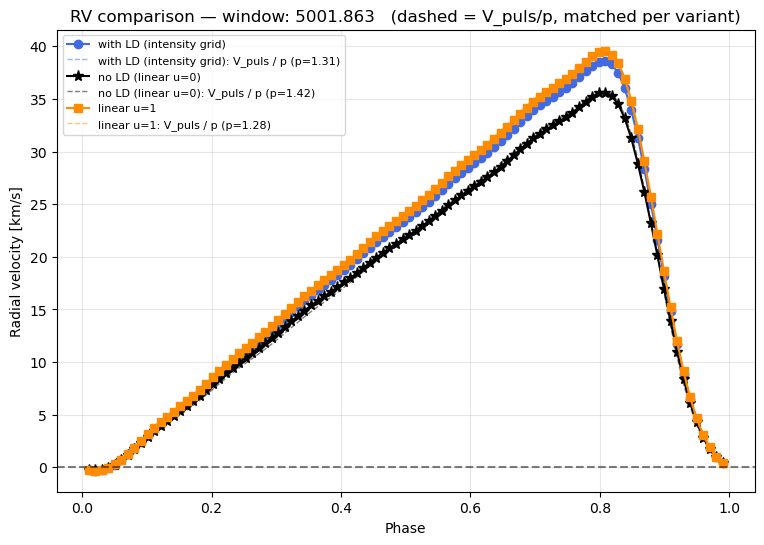

In [39]:
def plot_rv_comparison(window_key: str, save: str | None = None,
                       scale_truth: bool = True):
    """Plot recovered RVs against the on-mesh pulsation velocity.

    With ``scale_truth=True`` (default), the truth curve is divided by the
    per-variant projection factor (slope estimator), so each model's truth
    line lands on top of its observed RV when the model is consistent.
    Set to False to plot the bare V_puls (which sits a factor p above the
    observed curves by construction).
    """
    fig, ax = plt.subplots(figsize=(9, 6))
    pulsation_signed = pulsation_velocities - pulsation_velocities[0]

    def _add(variant, color, marker, label, markersize=6):
        if variant not in rv_table:
            return
        rv = rv_table[variant][window_key]
        ax.plot(phases[1:-1], rv[1:-1], c=color, marker=marker,
                markersize=markersize, label=label)
        if scale_truth:
            p, _ = _best_p(rv, pulsation_signed)
            if np.isfinite(p) and p != 0:
                ax.plot(phases[1:-1], pulsation_signed[1:-1] / p,
                        c=color, ls='--', lw=1.0, alpha=0.5,
                        label=f'{label}: V_puls / p (p={p:.2f})')

    _add('with_ld',         'royalblue',  'o', 'with LD (intensity grid)')
    _add('flux_linear_0.0', 'black',      '*', 'no LD (linear u=0)', markersize=8)
    _add('flux_linear_1.0', 'darkorange', 's', 'linear u=1')

    if not scale_truth:
        ax.plot(phases[1:-1], pulsation_signed[1:-1],
                c='coral', marker='o', label='V_puls (unscaled)', alpha=0.8)

    ax.axhline(0, color='black', linestyle='--', alpha=0.5)
    ax.set_xlabel('Phase'); ax.set_ylabel('Radial velocity [km/s]')
    title = f'RV comparison — window: {window_key}'
    if scale_truth:
        title += '   (dashed = V_puls/p, matched per variant)'
    ax.set_title(title)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    if save:
        fig.savefig(save, dpi=300)
    return fig


plot_rv_comparison('full', save='radial_velocities.pdf')
plt.show()

# Same comparison for the cleanest single-line anchor.
deepest_name = per_line_summary['RMS_vs_truth_kms'].idxmin().replace('Fe I ', '')
plot_rv_comparison(deepest_name)
plt.show()


## Projection factor table

`p = V_pulsation / RV_observed`, mean over all phases (skipping the t = 0
template). Rows are analysis windows, columns are LD variants. The
classical Cepheid p-factor lives in the 1.2–1.5 range; departures across
windows quantify how line-window choice biases the recovered radius
integration.


In [40]:
pulsation_signed = pulsation_velocities - pulsation_velocities[0]

window_keys = list(windows.keys())
rows = []
for win in window_keys:
    row = {'window': win, 'half_width_Å': 0.5 * (windows[win][1] - windows[win][0])}
    for variant in variants:
        rv = rv_table[variant][win]
        with np.errstate(divide='ignore', invalid='ignore'):
            ratio = pulsation_signed[1:] / rv[1:]
        row[variant] = float(np.nanmean(ratio))
    rows.append(row)

p_factor_df = pd.DataFrame(rows).set_index('window').reset_index()
p_factor_df


,window,half_width_Å,with_ld,flux_linear_0.0,flux_linear_0.1,flux_linear_0.2,flux_linear_0.3,flux_linear_0.4,flux_linear_0.6,flux_linear_0.7,flux_linear_0.8,flux_linear_0.9,flux_linear_1.0
0,full,10.0,1.235779,1.445175,1.425326,1.529925,1.418982,1.561494,1.094612,1.235947,1.230306,1.234842,1.220461
1,5001.863,1.5,1.216003,1.579081,1.307674,1.801549,1.400241,0.031995,1.194648,1.231439,1.240278,1.231716,1.182643
2,5002.791,1.5,1.265413,0.592656,1.317193,1.514812,1.603771,1.191189,1.292372,1.267931,1.255893,1.260712,1.223204
3,5006.119,1.5,1.247595,1.554645,1.498642,1.275284,1.257890,1.237916,1.163487,1.219394,1.251865,1.240552,1.224899
4,5007.212,1.5,1.414066,1.635589,1.615259,1.627170,1.636503,1.585348,1.569192,1.750110,1.422022,1.332656,1.362137
5,5014.942,1.5,1.242091,0.702704,1.447406,1.087952,1.543050,-0.642257,1.254407,1.250743,1.199319,1.194786,1.216117
6,5016.477,1.5,1.226802,1.918399,1.821404,1.242198,1.404679,1.022471,1.200179,1.242698,1.214754,1.198137,1.194759


### Regression-based projection factor

`mean(V_puls / RV_obs)` is biased: every snapshot where `RV_obs` crosses zero
produces a `1/RV_obs` blow-up that pollutes the mean. The unbiased estimator
for the slope of `V_puls = p · RV_obs` (no intercept) is

$$\hat p = \frac{\sum_t V_{\mathrm{puls},t}\, \mathrm{RV}_t}{\sum_t \mathrm{RV}_t^2}.$$

For linear LD against radial pulsation the analytical projection factor is
$p_{\mathrm{th}}(u) = 2(3-u)/(4-u)$, going from 1.500 at u=0 to 1.333 at u=1.


In [41]:
def _slope_p(rv, truth, min_rv=1e-3):
    rv = np.asarray(rv, dtype=float)[1:]
    truth = np.asarray(truth, dtype=float)[1:]
    good = np.isfinite(rv) & np.isfinite(truth) & (np.abs(rv) > min_rv)
    if good.sum() < 5:
        return np.nan
    return float(np.sum(rv[good] * truth[good]) / np.sum(rv[good] ** 2))


slope_rows = []
for win in window_keys:
    row = {'window': win, 'half_width_Å': 0.5 * (windows[win][1] - windows[win][0])}
    for variant in variants:
        row[variant] = _slope_p(rv_table[variant][win], pulsation_signed)
    slope_rows.append(row)

p_slope_df = pd.DataFrame(slope_rows).set_index('window')
p_slope_df


,half_width_Å,with_ld,flux_linear_0.0,flux_linear_0.1,flux_linear_0.2,flux_linear_0.3,flux_linear_0.4,flux_linear_0.6,flux_linear_0.7,flux_linear_0.8,flux_linear_0.9,flux_linear_1.0
window,,,,,,,,,,,,
full,10.0,1.332104,1.451357,1.436228,1.420481,1.404235,1.387480,1.370194,1.352510,1.334449,1.316124,1.297653
5001.863,1.5,1.312561,1.418653,1.404536,1.390081,1.375261,1.360065,1.344644,1.328861,1.312979,1.296841,1.280702
5002.791,1.5,1.340018,1.457586,1.442237,1.426460,1.410043,1.393212,1.375772,1.357927,1.339530,1.320923,1.302221
5006.119,1.5,1.338239,1.454830,1.440096,1.424859,1.409090,1.392782,1.376013,1.358773,1.341178,1.323269,1.305172
5007.212,1.5,1.402461,1.537035,1.520981,1.504153,1.486568,1.468238,1.449068,1.429021,1.408157,1.386460,1.363991
5014.942,1.5,1.322312,1.435158,1.420286,1.404956,1.389333,1.373373,1.357073,1.340529,1.323826,1.306800,1.289828
5016.477,1.5,1.331802,1.432881,1.419190,1.404996,1.390427,1.375448,1.360219,1.344615,1.328776,1.312747,1.296616


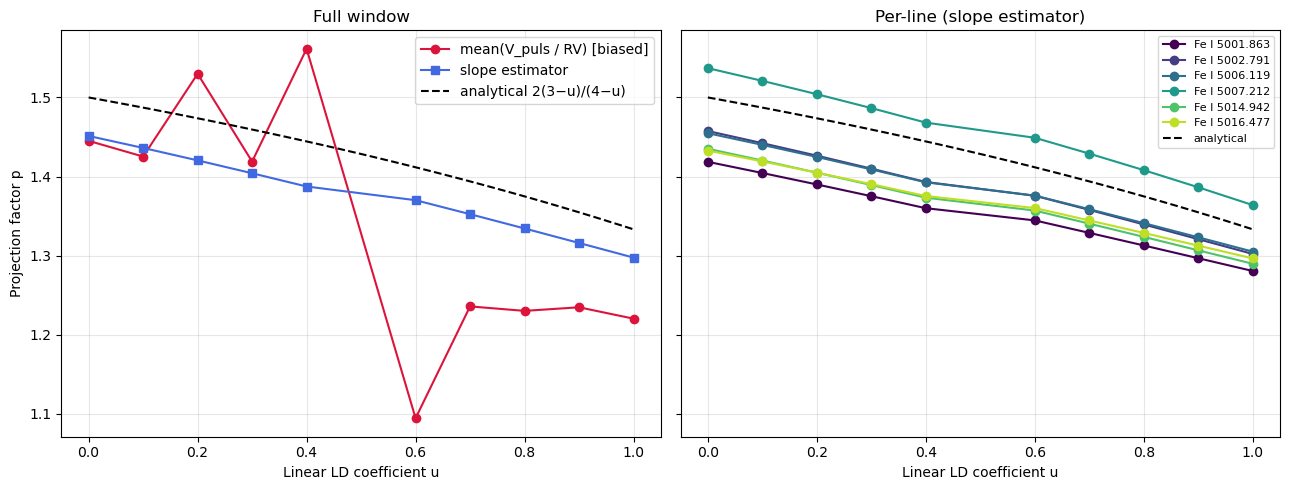

In [42]:
# Compare both estimators against the analytical curve p(u) = 2(3-u)/(4-u).
def p_theory(u):
    return 2.0 * (3.0 - u) / (4.0 - u)


u_grid = np.array([0.0, 0.1, 0.2, 0.3, 0.4, 0.6, 0.7, 0.8, 0.9, 1.0])
linear_variants = [f'flux_linear_{u:.1f}' for u in u_grid]
present = [v for v in linear_variants if v in variants]
u_present = np.array([float(v.split('_')[-1]) for v in present])

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)

# Full window: mean-of-ratios vs slope
mean_full = np.array([p_factor_df.set_index('window').loc['full', v] for v in present])
slope_full = np.array([p_slope_df.loc['full', v] for v in present])

axes[0].plot(u_present, mean_full, 'o-', color='crimson',
             label='mean(V_puls / RV) [biased]')
axes[0].plot(u_present, slope_full, 's-', color='royalblue',
             label='slope estimator')
u_fine = np.linspace(0, 1, 101)
axes[0].plot(u_fine, p_theory(u_fine), '--', color='black',
             label='analytical 2(3−u)/(4−u)')
axes[0].set_xlabel('Linear LD coefficient u')
axes[0].set_ylabel('Projection factor p')
axes[0].set_title('Full window')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Per-line: slope estimator only (mean-of-ratios is too noisy to be useful here).
colors = plt.cm.viridis(np.linspace(0, 0.9, len(FE_I_LINES)))
for (name, lc, ep), color in zip(FE_I_LINES, colors):
    key = name.replace('Fe I ', '')
    if key not in p_slope_df.index:
        continue
    p_line = np.array([p_slope_df.loc[key, v] for v in present])
    axes[1].plot(u_present, p_line, 'o-', color=color, label=name)
axes[1].plot(u_fine, p_theory(u_fine), '--', color='black',
             label='analytical')
axes[1].set_xlabel('Linear LD coefficient u')
axes[1].set_title('Per-line (slope estimator)')
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)

plt.tight_layout(); plt.show()
